In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
from google.colab import files

In [ ]:
# Degratation functions

# Haze degradation

# Transmission map: t(x) = e^(-beta*d(x))
# t(x) -> transmission: % of light that makes it to the camera lens
# d(x) -> distance: how far is the objec
# beta -> scattering costant. low value (0.005 to 0.015): light fog. high value (> 0.03) lot of fog

def add_synthetic_haze(image, beta=0.015, A=0.8):
    h, w, _ = image.shape
    z = np.linspace(1, 0, h).reshape(h, 1)                # Simulates depth (haze looks thicker further away)
    z = np.tile(z, (1, w))
    transmission = np.exp(-beta * (z * 60))               # How much of the original light reach the camera
    transmission = np.expand_dims(transmission, axis=2)
    hazy = image * transmission + A * (1 - transmission)
    return np.clip(hazy, 0, 1)




# SRRGAN degradation
def add_random_noise(img):
    if random.random() < 0.5:
        # Gaussian
        std = random.uniform(1/255.0, 15/255.0)
        noise = np.random.normal(0, std, img.shape)
        return np.clip(img + noise, 0, 1).astype(np.float32)
    else:
        # Poisson
        scale = random.uniform(10.0, 60.0)
        noisy = np.random.poisson(img * scale) / scale
        return np.clip(noisy, 0, 1).astype(np.float32)

def apply_jpeg(img):
    quality = random.randint(60, 95)
    img_uint8 = (img * 255).astype(np.uint8)
    _, buffer = cv2.imencode('.jpg', img_uint8, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    return cv2.imdecode(buffer, 1).astype(np.float32) / 255.0

def srrgan_degradation_pipeline(image, upscale_factor=2):
    curr = image.copy()

    # Blur
    if random.random() < 0.5:
        # Gaussian blur
        k = random.choice([3, 5, 7])
        curr = cv2.GaussianBlur(curr, (k, k), random.uniform(0.2, 1.2))
    else:
        # Box blur
        k = random.choice([3, 5])
        curr = cv2.blur(curr, (k, k))

    # Downsample
    h, w = curr.shape[:2]
    inter = random.choice([cv2.INTER_LINEAR, cv2.INTER_CUBIC, cv2.INTER_AREA])     # Bilinear, Bicubic, Area
    curr = cv2.resize(curr, (w // upscale_factor, h // upscale_factor), interpolation=inter)

    # Noise & JPEG (random)
    # Noise -> jpg
    if random.random() < 0.5:
        curr = add_random_noise(curr)
        if random.random() < 0.8: curr = apply_jpeg(curr)
    # Jpg -> Noise
    else:
        if random.random() < 0.8: curr = apply_jpeg(curr)
        curr = add_random_noise(curr)

    return np.clip(curr, 0, 1)

Saving IMG20251024132723.jpg to IMG20251024132723 (3).jpg


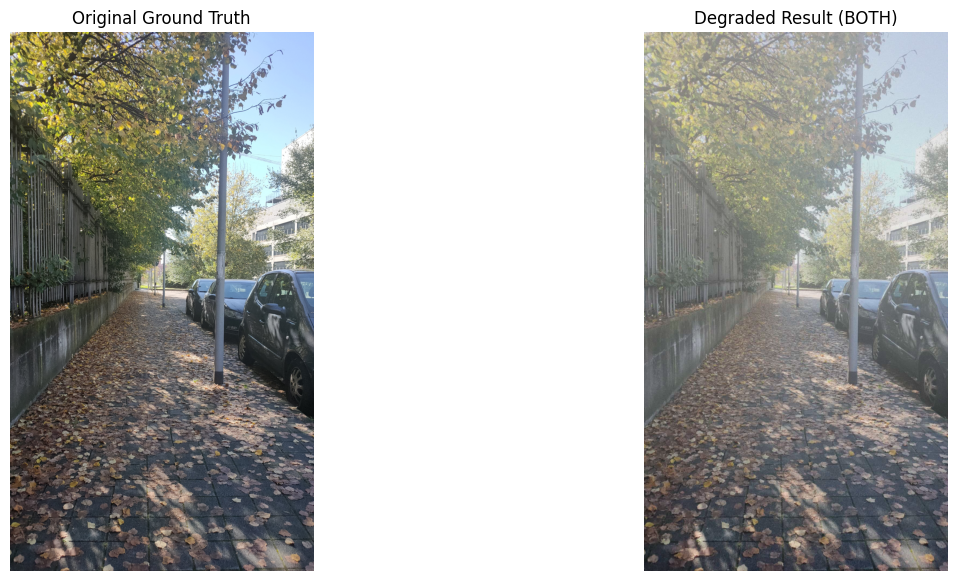

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CONTROL PANEL
# Options: "ONLY_HAZE", "ONLY_SRRGAN", "BOTH"
MODE = "BOTH"

# low value (0.005 to 0.01): light fog. high value (> 0.03) lot of fog
BETA_VALUE = 0.015
###############################################################################


# Upload Photo
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
original_pil = Image.open(img_path).convert("RGB")
img_float = np.array(original_pil).astype(np.float32) / 255.0

# Process based on Mode
if MODE == "ONLY_HAZE":
    output = add_synthetic_haze(img_float, beta=BETA_VALUE)
    filename = "degraded_haze_only.png"

elif MODE == "ONLY_SRRGAN":
    output = srrgan_degradation_pipeline(img_float)
    filename = "degraded_srrgan_only.png"

elif MODE == "BOTH":
    hazy_stage = add_synthetic_haze(img_float, beta=BETA_VALUE)
    output = srrgan_degradation_pipeline(hazy_stage)
    filename = "degraded_full_combined.png"

# Visualization
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(img_float)
plt.title("Original Ground Truth")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output)
plt.title(f"Degraded Result ({MODE})")
plt.axis('off')
plt.show()

# Save and download
final_output = Image.fromarray((output * 255).astype(np.uint8))
final_output.save(filename)
files.download(filename)